# **GreenLife Studio — CRM Sales Analysis**

**Author:** María Santos  
**Date:** March 2026  
**Tools:** Python, Pandas, Matplotlib, Seaborn  
**Data source:** HubSpot CRM export (March 2026)

##**Introduction**

GreenLife Studio is a London-based online fitness and wellness company that sells to two types of clients:

- **Individual clients (B2C):** Monthly memberships at £40/month and personal coaching at £200/month.
- **Corporate accounts (B2B):** Workplace wellness programmes at £2,000 per contract.

This analysis uses data exported from HubSpot CRM in March 2026. The goal is not just to describe the data — it is to answer real business questions that help GreenLife make better decisions about where to focus their sales energy.

## **Project Objectives**

The analysis answers four business questions:

1. **Where are deals getting stuck?** — Understanding which pipeline stages have the most deals helps identify conversion bottlenecks.

2. **How much revenue is realistically coming in?** — The difference between total pipeline value and weighted forecast reveals how much is truly at risk.

3. **Which segment drives more value — B2C or B2B?** — Knowing where the money is helps prioritize sales effort.

4. **Which deals need attention right now?** — Identifying the highest-value and highest-probability deals guides the team's weekly priorities.

## **Loading Data**

In [9]:
# Load all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

print('Libraries loaded successfully ✓')

Libraries loaded successfully ✓


In [10]:
# Upload CSV files exported from HubSpot
from google.colab import files
uploaded = files.upload()

Saving hubspot-crm-exports-all-contacts-2026-03-24-1.csv to hubspot-crm-exports-all-contacts-2026-03-24-1 (1).csv
Saving hubspot-crm-exports-my-deals-b2b-2026-03-24.csv to hubspot-crm-exports-my-deals-b2b-2026-03-24 (1).csv
Saving hubspot-crm-exports-my-deals-b2c-2026-03-24-1.csv to hubspot-crm-exports-my-deals-b2c-2026-03-24-1 (1).csv


In [11]:
# Load each file into a dataframe
contacts = pd.read_csv('hubspot-crm-exports-all-contacts-2026-03-24-1.csv')
deals_b2c = pd.read_csv('hubspot-crm-exports-my-deals-b2c-2026-03-24-1.csv')
deals_b2b = pd.read_csv('hubspot-crm-exports-my-deals-b2b-2026-03-24.csv')

# Label each deal with its pipeline type
deals_b2c['Pipeline Type'] = 'B2C'
deals_b2b['Pipeline Type'] = 'B2B'

# Combine both pipelines into one dataframe
deals = pd.concat([deals_b2c, deals_b2b], ignore_index=True)

print(f'Contacts:    {len(contacts)} rows')
print(f'Deals B2C:   {len(deals_b2c)} rows')
print(f'Deals B2B:   {len(deals_b2b)} rows')
print(f'Total deals: {len(deals)} rows')

Contacts:    13 rows
Deals B2C:   7 rows
Deals B2B:   5 rows
Total deals: 12 rows


In [12]:
# Preview the deals data
deals[['Deal Name', 'Deal Stage', 'Pipeline', 'Amount', 'Close Date']].head(12)

,Deal Name,Deal Stage,Pipeline,Amount,Close Date
0,Amelia Scott — Coaching 1:1,Free Trial / Intro Call,GreenLife B2C — Memberships & Coaching,200.0,2026-04-05 00:00
1,Daniel Osei — Online Membership,Free Trial / Intro Call,GreenLife B2C — Memberships & Coaching,40.0,2026-04-03 00:00
2,Sophie Williams — Online Membership,New Lead,GreenLife B2C — Memberships & Coaching,40.0,2026-04-15 00:00
3,Priya Patel — Coaching 1:1,Interested,GreenLife B2C — Memberships & Coaching,200.0,2026-04-08 00:00
4,James Carter — Online Membership,Interested,GreenLife B2C — Memberships & Coaching,40.0,2026-04-10 00:00
5,Rachel Kim — Coaching 1:1,Proposal Sent,GreenLife B2C — Memberships & Coaching,200.0,2026-03-28 00:00
6,Marcus Brown — Coaching 1:1,Closed Won,GreenLife B2C — Memberships & Coaching,200.0,2026-03-01 09:50
7,Nexa Group — Corporate Wellness,Initial Outreach,GreenLife B2B — Corporate Wellness,2000.0,2026-05-30 00:00
8,Stackbridge Tech — Corporate Wellness,Negotiation,GreenLife B2B — Corporate Wellness,2000.0,2026-03-31 00:00
9,Vericore Solutions — Corporate Wellness,Discovery Call,GreenLife B2B — Corporate Wellness,2000.0,2026-04-30 00:00


In [13]:
# Preview the contacts data
contacts[['First Name', 'Last Name', 'Job Title',
          'Lifecycle Stage', 'Lead Status']].head(13)

,First Name,Last Name,Job Title,Lifecycle Stage,Lead Status
0,Claire,Henderson,Head of People,Opportunity,In Progress
1,Daniel,Osei,Accountant,Opportunity,Open Deal
2,Fatima,Al-Hassan,HR Business Partner,Opportunity,Open
3,James,Carter,Software Engineer,Opportunity,Open
4,Amelia,Scott,Nurse,Opportunity,In Progress
5,Priya,Patel,Freelance Designer,Opportunity,In Progress
6,Robert,Ashford,Operations Director,Opportunity,Open Deal
7,Nadia,Kowalski,Wellbeing Lead,Opportunity,In Progress
8,Marcus,Brown,Personal Trainer,Customer,Open Deal
9,Tom,Hughes,Teacher,Lead,New


## Data Description

**Deals dataset** — 12 records across two pipelines:
- **Deal Name:** Name of the sales opportunity.
- **Deal Stage:** Current stage in the pipeline.
- **Pipeline:** B2C (Memberships & Coaching) or B2B (Corporate Wellness).
- **Amount:** Deal value in GBP.
- **Close Date:** Expected closing date.

**Contacts dataset** — 13 records:
- **Lifecycle Stage:** Where the contact is in the customer journey.
- **Lead Status:** Current operational status of the lead.

All records are complete with no missing values in key fields.

## **Data Preparation**

Before analyzing the data, we need to:
1. Select only the columns relevant to this analysis.
2. Rename them to simpler names for cleaner code.
3. Convert date columns to the correct format.

In [14]:
# Select only the columns we need
deals_clean = deals[[
    'Deal Name', 'Deal Stage', 'Pipeline Type',
    'Amount', 'Weighted amount in company currency',
    'Deal probability', 'Close Date', 'Is Closed Won'
]].copy()

# Rename to simpler names
deals_clean.columns = [
    'deal_name', 'deal_stage', 'pipeline_type',
    'amount', 'weighted_amount', 'probability',
    'close_date', 'is_won'
]

print('Columns selected and renamed ✓')

Columns selected and renamed ✓


In [15]:
# Convert date column to datetime format
deals_clean['close_date'] = pd.to_datetime(deals_clean['close_date'])

# Quick check
print(deals_clean[['deal_name', 'deal_stage', 'amount', 'probability']].to_string())

                                  deal_name               deal_stage  amount  probability
0               Amelia Scott — Coaching 1:1  Free Trial / Intro Call   200.0         0.50
1           Daniel Osei — Online Membership  Free Trial / Intro Call    40.0         0.50
2       Sophie Williams — Online Membership                 New Lead    40.0         0.05
3                Priya Patel — Coaching 1:1               Interested   200.0         0.20
4          James Carter — Online Membership               Interested    40.0         0.20
5                 Rachel Kim — Coaching 1:1            Proposal Sent   200.0         0.75
6               Marcus Brown — Coaching 1:1               Closed Won   200.0         1.00
7           Nexa Group — Corporate Wellness         Initial Outreach  2000.0         0.15
8     Stackbridge Tech — Corporate Wellness              Negotiation  2000.0         0.80
9   Vericore Solutions — Corporate Wellness           Discovery Call  2000.0         0.30
10     Bri

## Changes Made to the Dataset

- Selected 8 relevant columns from the full HubSpot export (which contained 100+ columns).
- Renamed all columns to lowercase snake_case for cleaner code.
- Converted `close_date` from text to `datetime` format.
- No duplicate records or missing values were found.


---
## **Analysis 1 — Where are deals getting stuck?**

**Business question:** How are deals distributed across pipeline stages?

**Why this matters:** In a healthy pipeline, deals flow progressively from early stages toward Closed Won. When deals pile up in the middle stages without advancing, it signals a conversion problem. Identifying where that bottleneck is tells us exactly what action to take.

In [16]:
# Count deals per stage for each pipeline
b2c = deals_clean[deals_clean['pipeline_type'] == 'B2C']
b2b = deals_clean[deals_clean['pipeline_type'] == 'B2B']

b2c_counts = b2c['deal_stage'].value_counts()
b2b_counts = b2b['deal_stage'].value_counts()

print('B2C deals by stage:')
print(b2c_counts)
print('\nB2B deals by stage:')
print(b2b_counts)

B2C deals by stage:
deal_stage
Free Trial / Intro Call    2
Interested                 2
New Lead                   1
Proposal Sent              1
Closed Won                 1
Name: count, dtype: int64

B2B deals by stage:
deal_stage
Discovery Call      2
Initial Outreach    1
Negotiation         1
Proposal Sent       1
Name: count, dtype: int64


In [17]:
# Define stage order and count deals per stage
b2c_order = ['New Lead', 'Interested', 'Free Trial / Intro Call',
             'Proposal Sent', 'Closed Won']
b2b_order = ['Initial Outreach', 'Discovery Call',
             'Proposal Sent', 'Negotiation']

b2c_counts = b2c['deal_stage'].value_counts().reindex(b2c_order, fill_value=0)
b2b_counts = b2b['deal_stage'].value_counts().reindex(b2b_order, fill_value=0)

print('Data ready for visualization ✓')

Data ready for visualization ✓


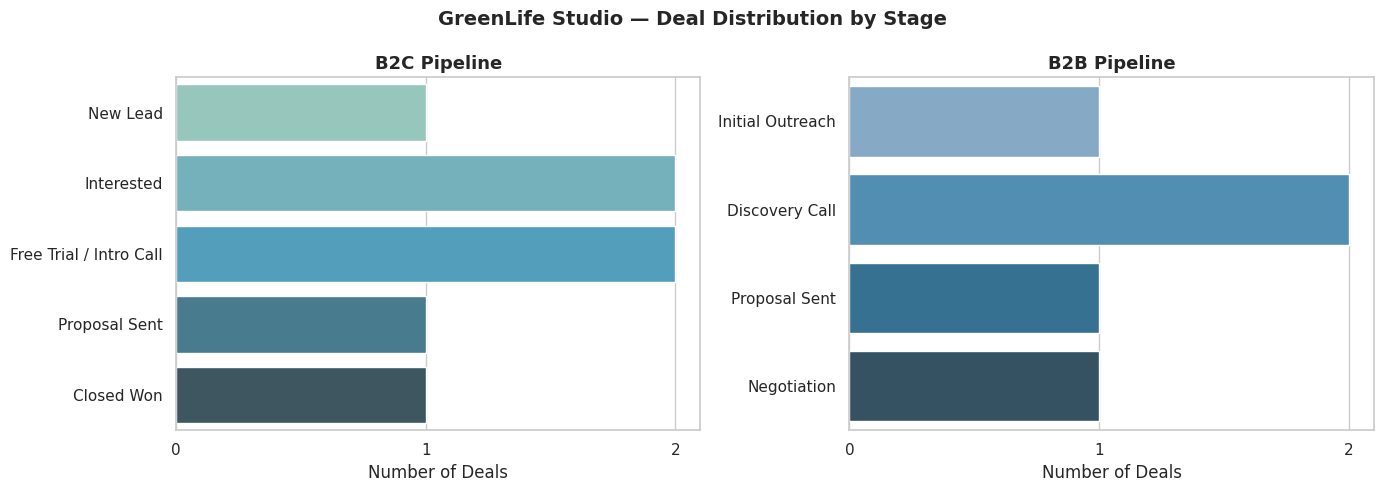

In [18]:
# Plot deal distribution by stage
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=b2c_counts.values, y=b2c_counts.index,
            hue=b2c_counts.index, palette='GnBu_d',
            legend=False, ax=axes[0])
axes[0].set_title('B2C Pipeline', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Deals')
axes[0].set_ylabel('')
axes[0].set_xticks([0, 1, 2])

sns.barplot(x=b2b_counts.values, y=b2b_counts.index,
            hue=b2b_counts.index, palette='PuBu_d',
            legend=False, ax=axes[1])
axes[1].set_title('B2B Pipeline', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Deals')
axes[1].set_ylabel('')
axes[1].set_xticks([0, 1, 2])

plt.suptitle('GreenLife Studio — Deal Distribution by Stage',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('greenlife_01_deal_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### **Findings and Conclusions**

**B2C Pipeline:**

- Deals are concentrated in the middle stages — 2 in Interested and 2 in Free Trial / Intro Call.

- Only 1 deal has reached Closed Won (Marcus Brown, £200).

- The drop from Free Trial to Proposal Sent suggests leads are not receiving a follow-up proposal after their session.


**B2B Pipeline:**

- No deals have closed yet — normal for a B2B cycle of 1 to 3 months.

- Discovery Call has the most activity with 2 deals in qualification.

- Stackbridge Tech in Negotiation is the most advanced deal in the entire pipeline.

**Business recommendation:** In B2C, implement a 48-hour proposal rule — every lead that completes a Free Trial must receive a proposal within 48 hours. In B2B, prioritize closing Stackbridge Tech before March 31.

---
## **Analysis 2 — How much revenue is realistically coming in?**

**Business question:** What is the difference between total pipeline value and what will actually close?

**Why this matters:** Having £10,920 in the pipeline does not mean GreenLife will receive £10,920. Each deal has a probability of closing based on its stage. The weighted forecast multiplies each deal's value by its probability — giving a realistic picture of expected revenue. The gap between the two numbers tells us how much is at risk.

In [19]:
# Calculate pipeline metrics
total_pipeline = deals_clean['amount'].sum()
weighted_forecast = (deals_clean['amount'] * deals_clean['probability']).sum()
total_won = deals_clean[deals_clean['is_won'] == True]['amount'].sum()

print(f'Total pipeline value:   £{total_pipeline:,.0f}')
print(f'Weighted forecast:      £{weighted_forecast:,.0f}')
print(f'Already closed won:     £{total_won:,.0f}')
print(f'Revenue at risk:        £{total_pipeline - weighted_forecast:,.0f}')

Total pipeline value:   £10,920
Weighted forecast:      £4,720
Already closed won:     £200
Revenue at risk:        £6,200


In [22]:
# Prepare data for visualization
labels = ['Total Pipeline', 'Weighted Forecast', 'Closed Won']
values = [total_pipeline, weighted_forecast, total_won]
colors = ['#2196A6', '#48B4C8', '#A8D8E0']

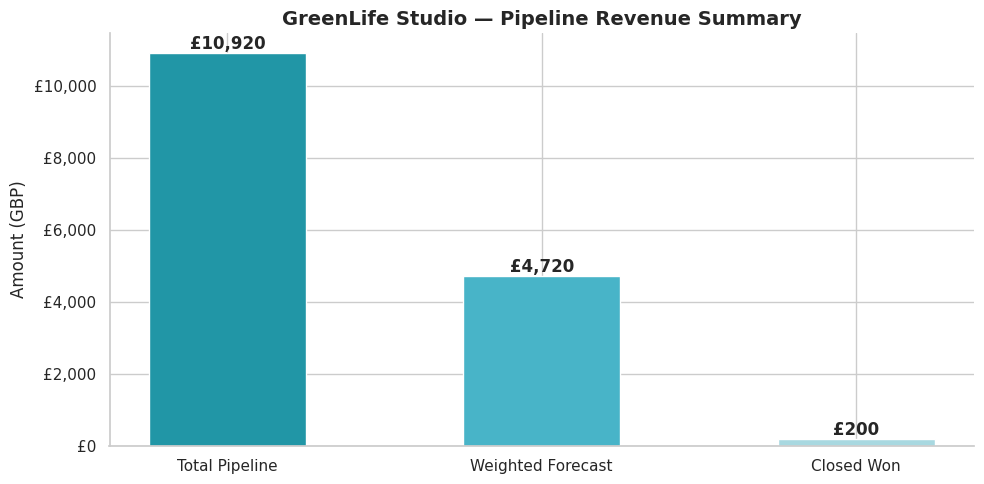

In [23]:
# Plot pipeline revenue summary
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(labels, values, color=colors, width=0.5, edgecolor='white')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 100,
            f'£{val:,.0f}',
            ha='center', fontsize=12, fontweight='bold')

ax.set_title('GreenLife Studio — Pipeline Revenue Summary',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Amount (GBP)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
sns.despine()
plt.tight_layout()
plt.savefig('greenlife_02_pipeline_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### **Findings and Conclusions**

- The total pipeline value is £10,920 — this is the optimistic scenario where every deal closes.
- The weighted forecast is £4,720 — this is the realistic projection after accounting for each deal's probability of closing.
- Only £200 has been confirmed so far (Marcus Brown, Coaching 1:1) — the only closed deal in the pipeline.
- The gap of £6,200 represents revenue that exists in the pipeline but is unlikely to close under current conditions.

**Is this a problem?** Not necessarily. GreenLife is a new business that launched its CRM this month. A pipeline of £10,920 in the first month is a strong start. However, two things need attention:

1. The B2C Free Trial bottleneck — leads are trying the service but not receiving proposals fast enough.
2. Stackbridge Tech closes March 31 — closing this one deal would bring in £2,000 and increase confirmed revenue by 10x.

---
## **Analysis 3 — Which segment drives more value: B2C or B2B?**

**Business question:** Where is the money in GreenLife's pipeline?

**Why this matters:** GreenLife sells to two very different types of clients. B2C deals are small and fast. B2B deals are large and slow. Understanding how each segment contributes to total revenue helps the team decide where to invest their time and energy. Because time is limited — you cannot chase everything equally.

In [25]:
# Revenue summary by pipeline type
revenue_by_type = deals_clean.groupby('pipeline_type').agg(
    total_value=('amount', 'sum'),
    weighted_value=('weighted_amount', 'sum'),
    deal_count=('deal_name', 'count'),
    avg_deal_size=('amount', 'mean')
).reset_index()

print(revenue_by_type)

  pipeline_type  total_value  weighted_value  deal_count  avg_deal_size
0           B2B      10000.0          4200.0           5    2000.000000
1           B2C        920.0           520.0           7     131.428571


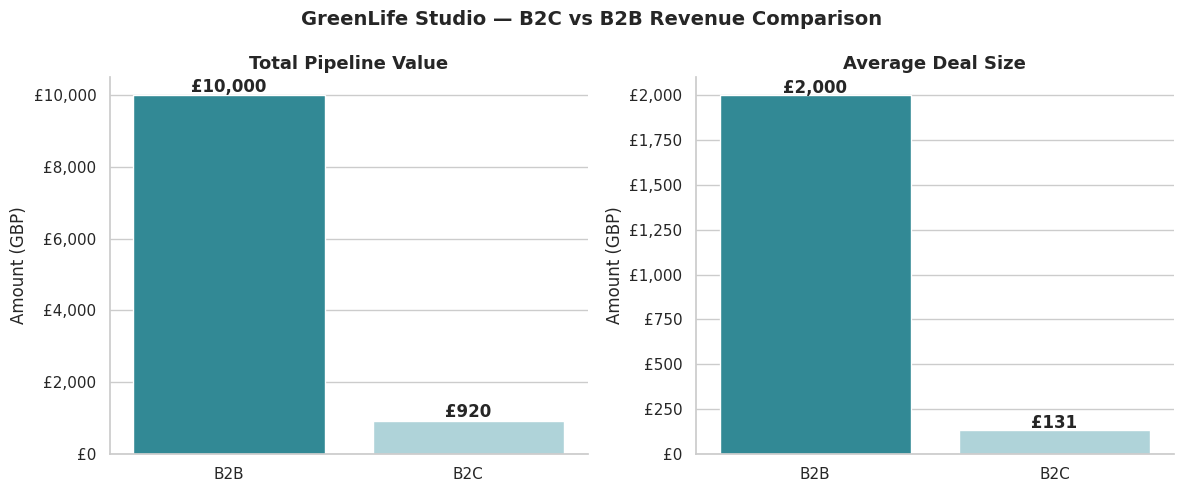

In [30]:
# B2C vs B2B revenue comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
palette = {'B2B': '#2196A6', 'B2C': '#A8D8E0'}

sns.barplot(data=revenue_by_type, x='pipeline_type', y='total_value',
            hue='pipeline_type', palette=palette, legend=False, ax=axes[0])
axes[0].set_title('Total Pipeline Value', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Amount (GBP)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2, p.get_height() + 100,
                f'£{p.get_height():,.0f}', ha='center', fontsize=12, fontweight='bold')

sns.barplot(data=revenue_by_type, x='pipeline_type', y='avg_deal_size',
            hue='pipeline_type', palette=palette, legend=False, ax=axes[1])
axes[1].set_title('Average Deal Size', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Amount (GBP)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 10,
                f'£{p.get_height():,.0f}', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('GreenLife Studio — B2C vs B2B Revenue Comparison',
             fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('greenlife_03_b2c_vs_b2b.png', dpi=150, bbox_inches='tight')
plt.show()

### **Findings and Conclusions**

- **B2B** generates £10,000 in total pipeline value vs £920 for B2C — 10 times more revenue despite having fewer deals.
- The average **B2B** deal is worth £2,000. The average **B2C** deal is worth £131 — a mix of £40 memberships and £200 coaching packages.

- This means GreenLife needs to close 15 **B2C** deals to match the revenue of a single **B2B** contract.

**Business recommendation:** B2B should be the priority for revenue growth. One corporate deal changes the numbers significantly. However, B2C memberships provide recurring monthly income — both channels are important but for different reasons.

---
## **Analysis 4 — Which deals need attention right now?**

**Business question:** Where should the sales team focus this week?

**Why this matters:** Not all open deals deserve equal attention. A deal closing in 7 days with 80% probability is completely different from one closing in 60 days with 20% probability. Good operations means knowing how to prioritize — combining close date, deal value, and probability to decide where to act first.

In [31]:
# Filter open deals and calculate days until close
today = pd.Timestamp('2026-03-24')
open_deals = deals_clean[deals_clean['is_won'] != True].copy()
open_deals['days_until_close'] = (open_deals['close_date'] - today).dt.days

# Short name for readability
open_deals['short_name'] = open_deals['deal_name'].str.split('—').str[0].str.strip()

# Show deals sorted by closest deadline
print(open_deals[['short_name', 'deal_stage', 'amount', 'probability', 'days_until_close']]
      .sort_values('days_until_close')
      .to_string(index=False))

        short_name              deal_stage  amount  probability  days_until_close
        Rachel Kim           Proposal Sent   200.0         0.75                 4
  Stackbridge Tech             Negotiation  2000.0         0.80                 7
       Daniel Osei Free Trial / Intro Call    40.0         0.50                10
      Amelia Scott Free Trial / Intro Call   200.0         0.50                12
       Priya Patel              Interested   200.0         0.20                15
      James Carter              Interested    40.0         0.20                17
   Sophie Williams                New Lead    40.0         0.05                22
   Brightworks Ltd           Proposal Sent  2000.0         0.55                22
Vericore Solutions          Discovery Call  2000.0         0.30                37
Atlas Retail Group          Discovery Call  2000.0         0.30                52
        Nexa Group        Initial Outreach  2000.0         0.15                67


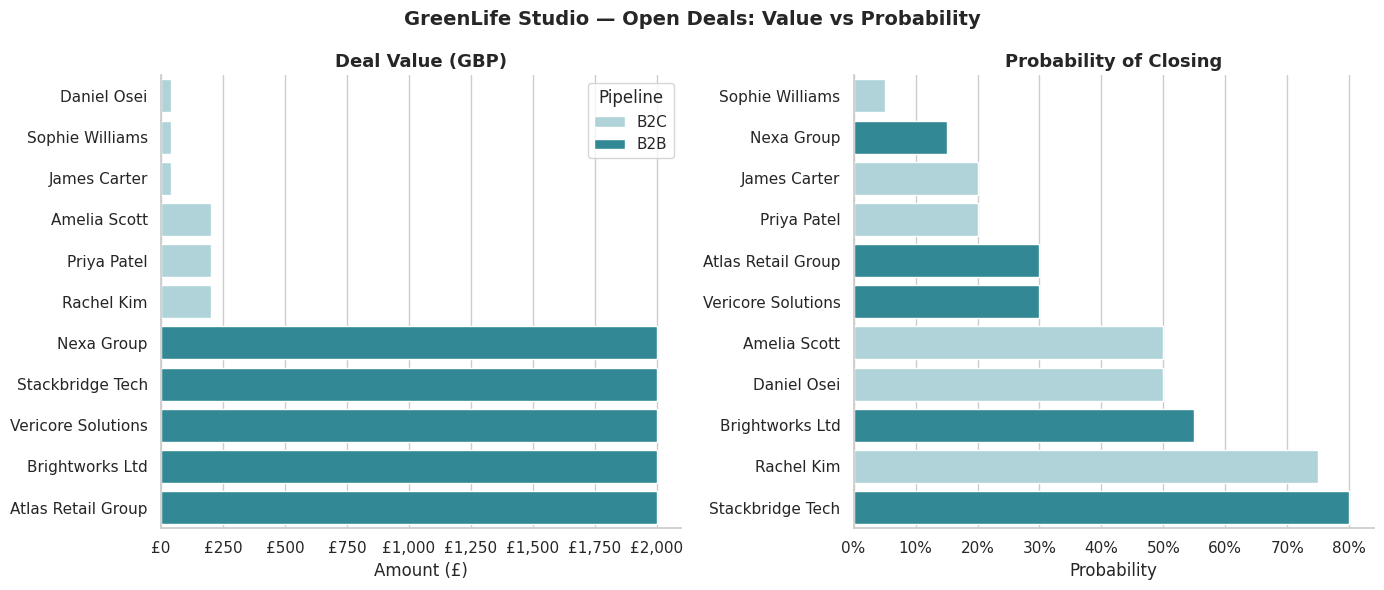

In [32]:
# Plot open deals by value and probability
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

open_deals_sorted = open_deals.sort_values('amount', ascending=True)

sns.barplot(y='short_name', x='amount', data=open_deals_sorted,
            hue='pipeline_type', palette={'B2B': '#2196A6', 'B2C': '#A8D8E0'},
            legend=True, ax=axes[0])
axes[0].set_title('Deal Value (GBP)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Amount (£)')
axes[0].set_ylabel('')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
axes[0].legend(title='Pipeline')

open_deals_sorted2 = open_deals.sort_values('probability', ascending=True)
sns.barplot(y='short_name', x='probability', data=open_deals_sorted2,
            hue='pipeline_type', palette={'B2B': '#2196A6', 'B2C': '#A8D8E0'},
            legend=False, ax=axes[1])
axes[1].set_title('Probability of Closing', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Probability')
axes[1].set_ylabel('')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('GreenLife Studio — Open Deals: Value vs Probability',
             fontsize=14, fontweight='bold')
sns.despine()
plt.tight_layout()
plt.savefig('greenlife_04_open_deals.png', dpi=150, bbox_inches='tight')
plt.show()

### **Findings and Conclusions**

- The 5 B2B deals dominate by value — all worth £2,000 each, dwarfing the B2C deals.

- Stackbridge Tech has the highest probability of closing (80%) AND the highest value (£2,000) — making it the single most important deal in the pipeline.

- Rachel Kim has the second highest probability (75%) and closes in 4 days — requires immediate action.

- The B2C deals with the highest probability (Rachel Kim, Amelia Scott, Daniel Osei) are all in advanced stages — proposals should be followed up this week.

**Business recommendation:** The priority this week is clear — close Stackbridge Tech and Rachel Kim. Together they represent £2,200 and have the highest probability of closing. Missing either of these deals would be a significant loss given how early GreenLife is in its revenue journey.

---
## **Overall Conclusions and Recommendations**

This analysis of GreenLife Studio's HubSpot CRM data reveals a business with a strong pipeline for its first month, but with clear opportunities to improve conversion and prioritize the right deals.

**Key takeaways:**

1. **The pipeline is healthy but conversion is low.** £10,920 in total value with only £200 confirmed is normal for a new business — but the team needs to act now to move deals forward.

2. **B2B is where the money is.** One corporate deal (£2,000) equals 15 B2C memberships. Prioritizing B2B outreach will have the biggest impact on revenue.

3. **B2C has a follow-up problem.** Leads are entering the pipeline and trying the service but not receiving proposals fast enough. A 48-hour proposal rule after every Free Trial would fix this.

4. **Two deals need attention this week.** Stackbridge Tech (£2,000, 80% probability, closes March 31) and Rachel Kim (£200, 75% probability, closes March 28) are the highest priority actions right now.

**Final thought:** Good CRM management is not about having the most contacts or the biggest pipeline — it is about knowing exactly where to focus. This analysis shows that GreenLife's team can close £2,200 this week alone if they act on the right deals at the right time.